In [1]:
import src.utils
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import seaborn as sns

## RNG
rng = np.random.default_rng()

## color palette
sns.set(rc={"axes.facecolor": "white", "axes.grid": False}, palette="colorblind")

## funcs

In [2]:
def get_windowed(x):
    return src.utils.get_windowed(x, stride=60, window_size=480)


def get_ddx(x, lons_w=slice(150, 190), lons_e=slice(240, 280)):
    """compute horizontal gradient"""

    ## ranges
    lat_range = dict(latitude=slice(-5, 5))
    # lon_range_w = dict(longitude=slice(120, 160))
    # lon_range_e = dict(longitude=slice(210, 270))
    lon_range_w = dict(longitude=lons_w)
    lon_range_e = dict(longitude=lons_e)

    ## spatial avg
    avg = lambda x: x.mean(["latitude", "longitude"])

    ## get east and west
    Tw = avg(x.sel(**lon_range_w, **lat_range))
    Te = avg(x.sel(**lon_range_e, **lat_range))

    return Te - Tw


def get_T34(x):
    """compute horizontal gradient"""

    ## ranges
    lat_range = dict(latitude=slice(-5, 5))
    lon_range = dict(longitude=slice(190, 240))

    ## spatial avg
    avg = lambda x: x.mean(["latitude", "longitude"])

    ## get east and west
    T34 = avg(x.sel(**lon_range, **lat_range))

    return T34

### Load CESM2 data

In [3]:
## specify lons for grad
LONS_W = slice(140, 190)
LONS_E = slice(240, 280)
# LONS_W = slice(120,180)
# LONS_E = slice(180,280)

## get_ddx helper
get_ddx_ = lambda x: get_ddx(x, lons_e=LONS_E, lons_w=LONS_W)

## load data
forced, anom = src.utils.load_consolidated()

## subset for temperature
sst = xr.merge([forced[["sst_comp"]], forced["sst"] + anom["sst"]])
ssta = anom[["sst", "sst_comp"]]

## compute grad
dTdx = get_windowed(src.utils.reconstruct_wrapper(sst, get_ddx_)["sst"])
T34 = get_windowed(src.utils.reconstruct_wrapper(sst, get_T34)["sst"])
T34_a = get_windowed(src.utils.reconstruct_wrapper(ssta, get_T34)["sst"])
x = xr.merge([dTdx.rename("dTdx"), T34.rename("T34"), T34_a.rename("T34_a")])

## subset for DJF
x = x.resample({"time": "QS-DEC"}).mean()
x = x.sel(time=slice("1850-12-01", "1888-12-01", 4)).sel(year=1900)
x = x.stack(s=["time", "member"])

### get best fit

In [4]:
coefs = x["dTdx"].assign_coords({"T": x.T34_a}).polyfit(dim="T", deg=2).to_dataarray()
coefs = coefs.values.flatten()

f = lambda x: coefs[0] * x**2 + coefs[1] * x + coefs[2]
f_sym = lambda x: coefs[1] * x + coefs[2]

Plot nonlinear relation

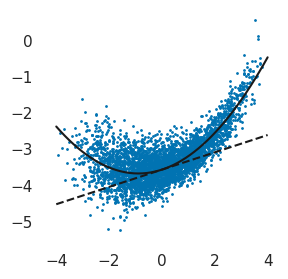

In [5]:
fig, ax = plt.subplots(figsize=(3, 3))
ax.scatter(x["T34_a"], x["dTdx"], s=1)
ax.plot(np.linspace(-4, 4), f(np.linspace(-4, 4)), c="k")
ax.plot(np.linspace(-4, 4), f_sym(np.linspace(-4, 4)), c="k", ls="--")

### Stochastic timeseries

#### Generate random data

In [6]:
## specify trend in sigma (K/century)
sigma_trend = -0.4

## number of years/members for simulation
n_years = 40
n_member = 30000

## generate series of sigma over time
years = np.arange(n_years)
sigma_T34 = 1 + (1e-2 * sigma_trend) * years

## generate random series
T34 = sigma_T34[None, :] * rng.normal(size=(n_member, n_years))

## put in xarray
coords = dict(member=np.arange(n_member), year=years)
T34 = xr.DataArray(T34, coords=coords, dims=["member", "year"])

#### compute trends

In [7]:
get_trend = (
    lambda z: 100 * z.polyfit(dim="year", deg=1).to_dataarray().sel(degree=1).squeeze()
)
trend_fsym = get_trend(f_sym(T34))
trend_f = get_trend(f(T34))

#### Plot

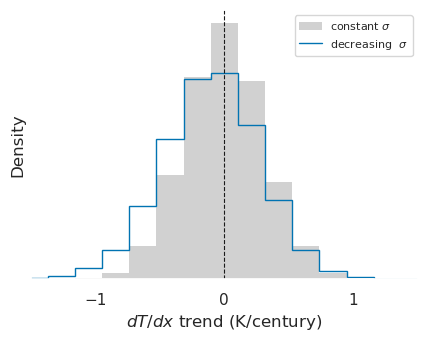

In [8]:
edges = np.linspace(-2, 2, 20)
get_pdf = lambda y: src.utils.get_empirical_pdf(y.values, edges=edges)[0]
pdf = get_pdf(trend_fsym)
pdf_f = get_pdf(trend_f)

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.stairs(pdf, edges, fill=True, alpha=0.2, color="k", label=r"constant $\sigma$")
ax.stairs(pdf_f, edges, label=r"decreasing  $\sigma$")
ax.set_xlim([-1.5, 1.5])
ax.axvline(0, ls="--", c="k", lw=0.8)
ax.legend(prop=dict(size=8))
ax.set_xticks([-1, 0, 1])
ax.set_yticks([])
ax.set_xlabel(r"$dT/dx$ trend (K/century)")
ax.set_ylabel(r"Density")

plt.show()

## Decompose horizontal grad

In [9]:
## compute grad
dTdx = get_windowed(src.utils.reconstruct_wrapper(sst, get_ddx_)["sst"])
# T34 = get_windowed(src.utils.reconstruct_wrapper(sst, get_T34)["sst"])
T34_a = get_windowed(src.utils.reconstruct_wrapper(ssta, get_T34)["sst"])
x = xr.merge([dTdx.rename("dTdx"), T34_a.rename("T34_a")])

## subset for DJF
x = x.resample({"time": "QS-DEC"}).mean()
x = x.sel(time=slice("1850-12-01", "1888-12-01", 4))

In [10]:
## compute metrics
sigma_T = x["T34_a"].std("time")
dTdx_ = x["dTdx"].mean("time")
const = xr.ones_like(sigma_T)

## put in xarray
data = xr.merge(
    [sigma_T.rename("sigma_T"), dTdx_.rename("dTdx"), const.rename("const")]
)
data = data.transpose("year", ...)

In [11]:
import sklearn.linear_model

LR = sklearn.linear_model.LinearRegression

In [19]:
## empty array to hold results
coefs = []

## loop thru years
for year in data.year:

    ## get data
    X = data["sigma_T"].sel(year=year)
    Y = data["dTdx"].sel(year=year)

    ## instantiate model
    mod = LR(fit_intercept=True)
    mod.fit(X=X.values[:, None], y=Y.values)

    coefs.append(np.array([mod.coef_.item(), mod.intercept_]))

## put coefs in array
coefs = np.stack(coefs, axis=0)

## put everything in xarray
data["dTdx_bar"] = coefs[:, 1]
data["dTdx_star"] = coefs[:, :1] * data["sigma_T"]
data["dTdx_star_const"] = coefs[0, 0] * data["sigma_T"]
data["dTdx_bar_res"] = data["dTdx"] - data["dTdx_star"]
data["dTdx_bar_const"] = data["dTdx"] - data["dTdx_star_const"]
data["m"] = coefs[:, 0]

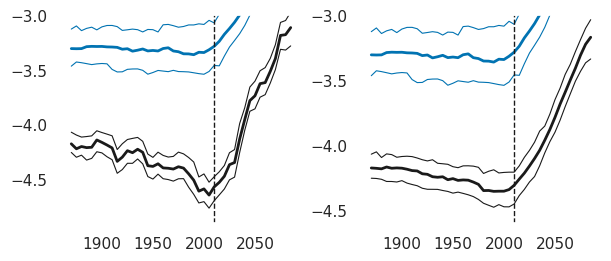

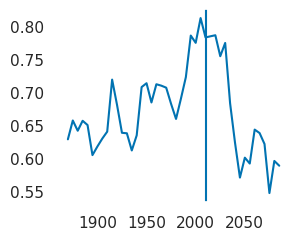

In [20]:
fig, axs = plt.subplots(1, 2, figsize=(6, 2.5), layout="constrained")
# ax.plot(data.year, data["dTdx_bar"])

for ax, v in zip(axs, ["dTdx_bar_res", "dTdx_bar_const"]):

    for q, lw in zip([0.5, 0.05, 0.95], [2, 0.8, 0.8]):
        sel_ = lambda x: x.quantile(q=q, dim="member")

        ## plot corrected
        ax.plot(data.year, sel_(data[v]), lw=lw, c="k")

        ## plot raw
        ax.plot(data.year, sel_(data["dTdx"]), lw=lw, c=sns.color_palette()[0])

    ax.axvline(2010, c="k", ls="--", lw=1)
    ax.set_ylim([None, -3])

plt.show()

fig, ax = plt.subplots(figsize=(3, 2.5))
# ax.plot(data.year, xr.corr(data["dTdx"], data["sigma_T"], dim="member"))
ax.plot(data.year, data["m"])
ax.axvline(2010)
plt.show()

could do same thing with El Niño/La Niña composite...(instead of regression)

In [21]:
X = data["sigma_T"].isel(year=0)
Y = data["dTdx"].isel(year=0)

In [26]:
mod.fit(X=X.values[:, None], y=Y.values)
mod.coef_
mod.intercept_

np.float64(-4.176167967228084)

In [13]:
help(LR.fit)

Help on function fit in module sklearn.linear_model._base:

fit(self, X, y, sample_weight=None)
    Fit linear model.

    Parameters
    ----------
    X : {array-like, sparse matrix} of shape (n_samples, n_features)
        Training data.

    y : array-like of shape (n_samples,) or (n_samples, n_targets)
        Target values. Will be cast to X's dtype if necessary.

    sample_weight : array-like of shape (n_samples,), default=None
        Individual weights for each sample.

        .. versionadded:: 0.17
           parameter *sample_weight* support to LinearRegression.

    Returns
    -------
    self : object
        Fitted Estimator.



In [76]:
data["sigma_T"]

<xarray.DataArray 'sigma_T' (member: 100, year: 44)> Size: 35kB
array([[1.47857942, 1.37624101, 1.38552713, ..., 1.43613036, 1.34299719,
        1.38500674],
       [1.20258679, 1.24694011, 1.23882993, ..., 1.46355457, 1.40175061,
        1.41526888],
       [1.5220587 , 1.59995077, 1.51689999, ..., 1.52183925, 1.48531459,
        1.4567393 ],
       ...,
       [1.28148839, 1.33079641, 1.36676388, ..., 1.65935146, 1.53492553,
        1.54866909],
       [1.33551812, 1.3831499 , 1.46544127, ..., 1.445015  , 1.32968099,
        1.35928899],
       [1.35764935, 1.29886158, 1.35189493, ..., 1.63663999, 1.61838613,
        1.57968156]], shape=(100, 44))
Coordinates:
  * member   (member) int64 800B 0 1 2 3 4 5 6 7 8 ... 92 93 94 95 96 97 98 99
  * year     (year) int64 352B 1870 1875 1880 1885 1890 ... 2070 2075 2080 2085

In [48]:
## calc. stats
m = src.utils.regress_core(X=sigma_T, Y=dTdx_, dim="member")

In [57]:
def multi_regress(data, y_var, x_vars, dim="member"):
    """multiple linear regression"""

    ## Get covariates and targets
    X = data[x_vars].to_dataarray(dim="i")
    Y = data[y_var]

    ## compute covariance matrices
    YXt = xr.cov(Y, X, dim=dim)
    XXt = xr.cov(X, X.rename({"i": "j"}), dim=dim)

    ## invert XX^T
    XXt_inv = xr.zeros_like(XXt)
    XXt_inv.values = np.linalg.inv(XXt.values)

    ## get least-squares fit, YX^T @ (XX^T)^{-1}
    coefs = (YXt * XXt_inv).sum("i")

    return coefs

In [69]:
XXt

<xarray.DataArray (i: 2, year: 44, j: 2)> Size: 1kB
array([[[0.01934545, 0.        ],
        [0.01819211, 0.        ],
        [0.01641373, 0.        ],
        [0.01595063, 0.        ],
        [0.01525968, 0.        ],
        [0.01746284, 0.        ],
        [0.02015205, 0.        ],
        [0.0217499 , 0.        ],
        [0.02553624, 0.        ],
        [0.02288011, 0.        ],
        [0.02422774, 0.        ],
        [0.02182614, 0.        ],
        [0.02043602, 0.        ],
        [0.02126704, 0.        ],
        [0.0225306 , 0.        ],
        [0.02220411, 0.        ],
        [0.02181694, 0.        ],
        [0.02311597, 0.        ],
        [0.02286754, 0.        ],
        [0.02476964, 0.        ],
...
        [0.        , 0.        ],
        [0.        , 0.        ],
        [0.        , 0.        ],
        [0.        , 0.        ],
        [0.        , 0.        ],
        [0.        , 0.        ],
        [0.        , 0.        ],
        [0.        , 0.        ],
        [0.        , 0.        ],
        [0.        , 0.        ],
        [0.        , 0.        ],
        [0.        , 0.        ],
        [0.        , 0.        ],
        [0.        , 0.        ],
        [0.        , 0.        ],
        [0.        , 0.        ],
        [0.        , 0.        ],
        [0.        , 0.        ],
        [0.        , 0.        ],
        [0.        , 0.        ]]])
Coordinates:
  * year     (year) int64 352B 1870 1875 1880 1885 1890 ... 2070 2075 2080 2085
  * i        (i) object 16B 'sigma_T' 'const'
  * j        (j) object 16B 'sigma_T' 'const'

In [72]:
XXt

<xarray.DataArray (i: 2, j: 2)> Size: 32B
array([[0.01934545, 0.        ],
       [0.        , 0.        ]])
Coordinates:
    year     int64 8B 1870
  * i        (i) object 16B 'sigma_T' 'const'
  * j        (j) object 16B 'sigma_T' 'const'

In [71]:
data_ = data.isel(year=0)
X = data_[["sigma_T", "const"]].to_dataarray(dim="i")
Y = data_["dTdx"]

dim = "member"

## compute covariance matrices
YXt = xr.cov(Y, X, dim=dim)
XXt = xr.cov(X, X.rename({"i": "j"}), dim=dim)

## invert XX^T
XXt_inv = xr.zeros_like(XXt)
XXt_inv.values = np.linalg.inv(XXt.values)

LinAlgError: Singular matrix

In [59]:
multi_regress(
    data.isel(year=0), y_var="dTdx", x_vars=["sigma_T", "const"], dim=["member"]
)

LinAlgError: Singular matrix

In [40]:
coefs = src.utils.regress_core(X=sigma_T, Y=dTdx_, dim="member")

<xarray.DataArray 'T34_a' (member: 100, year: 44)> Size: 35kB
array([[1.47857942, 1.37624101, 1.38552713, ..., 1.43613036, 1.34299719,
        1.38500674],
       [1.20258679, 1.24694011, 1.23882993, ..., 1.46355457, 1.40175061,
        1.41526888],
       [1.5220587 , 1.59995077, 1.51689999, ..., 1.52183925, 1.48531459,
        1.4567393 ],
       ...,
       [1.28148839, 1.33079641, 1.36676388, ..., 1.65935146, 1.53492553,
        1.54866909],
       [1.33551812, 1.3831499 , 1.46544127, ..., 1.445015  , 1.32968099,
        1.35928899],
       [1.35764935, 1.29886158, 1.35189493, ..., 1.63663999, 1.61838613,
        1.57968156]], shape=(100, 44))
Coordinates:
  * member   (member) int64 800B 0 1 2 3 4 5 6 7 8 ... 92 93 94 95 96 97 98 99
  * year     (year) int64 352B 1870 1875 1880 1885 1890 ... 2070 2075 2080 2085

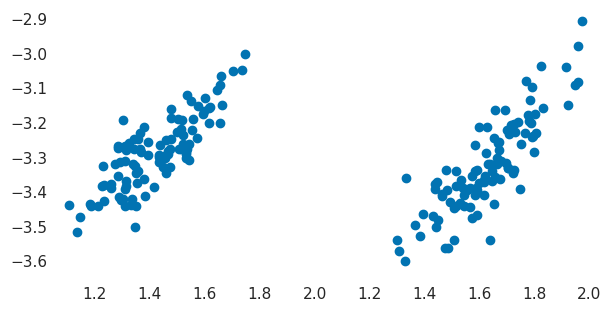

In [38]:
fig, axs = plt.subplots(1, 2, figsize=(6, 3), layout="constrained")

for ax, year in zip(axs, [1900, 2000]):

    ax.scatter(sigma_T.sel(year=year), dTdx_.sel(year=year))


## formatting
src.utils.set_lims(axs)

for ax in axs[1:]:
    ax.set_yticks([])


plt.show()